# 02. Otomobil Yakıt Verimliliği Tahmini

**Kategori:** Regresyon  
**Gerçek veri seti:** UCI Auto MPG  
**Veri kaynağı:** [https://archive.ics.uci.edu/dataset/9/auto+mpg](https://archive.ics.uci.edu/dataset/9/auto+mpg)  
**Amaç:** Motor ve araç özelliklerinden mil/galon (MPG) değerini tahmin etmek.

Bu notebook; veri yükleme, veri kalitesi kontrolü, keşifsel veri analizi (EDA), görselleştirme,
modelleme, değerlendirme ve çıktı yorumlama adımlarını ayrı ayrı gösterir. Sentetik veya rastgele
üretilmiş gözlem kullanılmamıştır. Rastgelelik yalnızca tekrarlanabilir eğitim/test ayrımı ve
algoritma başlangıcı için `random_state=42` ile kontrol edilmiştir.

In [1]:
from pathlib import Path
import json, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"
MODEL_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)
print("Proje kökü:", ROOT.resolve())

Proje kökü: /workspace/scratch/f0b9bcae3580/Rabia_Yel_21_Gercek_Veri_Projesi


## 1. Veriyi tanıma

In [2]:
df = pd.read_csv(DATA_DIR / "auto_mpg.csv")
display(df.head())
display(pd.DataFrame({"tip": df.dtypes, "eksik": df.isna().sum()}))
print("Boyut:", df.shape, "| Tekrarlı satır:", df.duplicated().sum())

Boyut: (398, 9) | Tekrarlı satır: 0


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


,tip,eksik
mpg,float64,0
cylinders,int64,0
displacement,float64,0
horsepower,float64,6
weight,float64,0
acceleration,float64,0
model_year,int64,0
origin,int64,0
car_name,object,0


## 2. EDA

,count,mean,std,min,25%,50%,75%,max
mpg,398.0,23.514573,7.815984,9.0,17.500,23.0,29.000,46.6
cylinders,398.0,5.454774,1.701004,3.0,4.000,4.0,8.000,8.0
displacement,398.0,193.425879,104.269838,68.0,104.250,148.5,262.000,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.5,126.000,230.0
weight,398.0,2970.424623,846.841774,1613.0,2223.750,2803.5,3608.000,5140.0
acceleration,398.0,15.568090,2.757689,8.0,13.825,15.5,17.175,24.8
model_year,398.0,76.010050,3.697627,70.0,73.000,76.0,79.000,82.0
origin,398.0,1.572864,0.802055,1.0,1.000,1.0,2.000,3.0


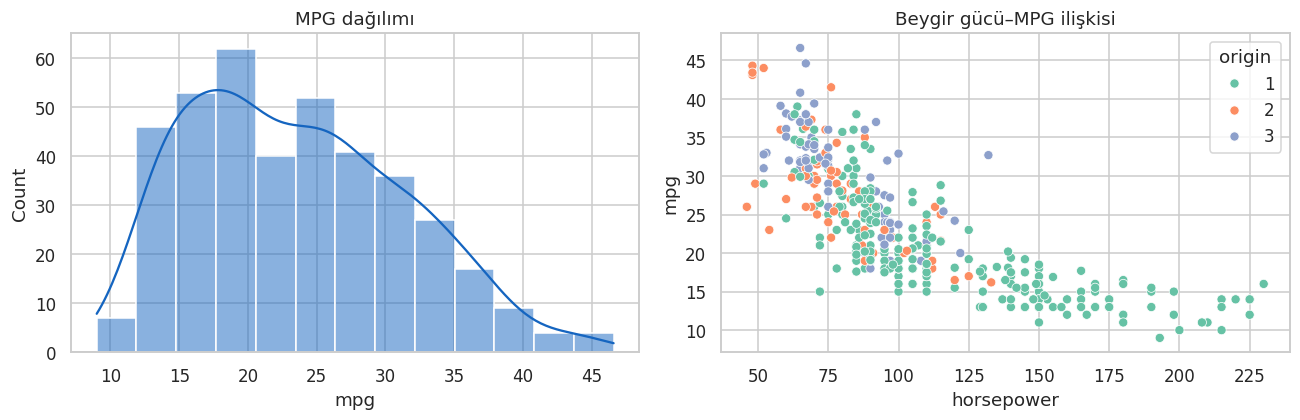

In [3]:
display(df.describe().T)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df.mpg, kde=True, ax=axes[0], color="#1565C0")
axes[0].set(title="MPG dağılımı")
sns.scatterplot(data=df, x="horsepower", y="mpg", hue="origin", palette="Set2", ax=axes[1])
axes[1].set(title="Beygir gücü–MPG ilişkisi")
plt.tight_layout(); plt.show()

## 3. Modelleme

In [4]:
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

features = ["cylinders", "displacement", "horsepower", "weight",
            "acceleration", "model_year", "origin"]
X, y = df[features], df["mpg"]
numeric = features[:-1]
preprocess = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), numeric),
    ("origin", OneHotEncoder(handle_unknown="ignore"), ["origin"]),
])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, random_state=RANDOM_STATE
)
candidates = {
    "Doğrusal Regresyon": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=250, min_samples_leaf=2,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}
fitted = {name: make_pipeline(clone(preprocess), model).fit(X_train, y_train)
          for name, model in candidates.items()}
preds = {name: model.predict(X_test) for name, model in fitted.items()}
scores = pd.DataFrame({name: {"MAE": mean_absolute_error(y_test, pred),
                              "RMSE": root_mean_squared_error(y_test, pred),
                              "R2": r2_score(y_test, pred)}
                       for name, pred in preds.items()}).T.sort_values("MAE")
display(scores.round(3))

,MAE,RMSE,R2
Random Forest,1.514,2.004,0.925
Doğrusal Regresyon,2.288,2.888,0.845


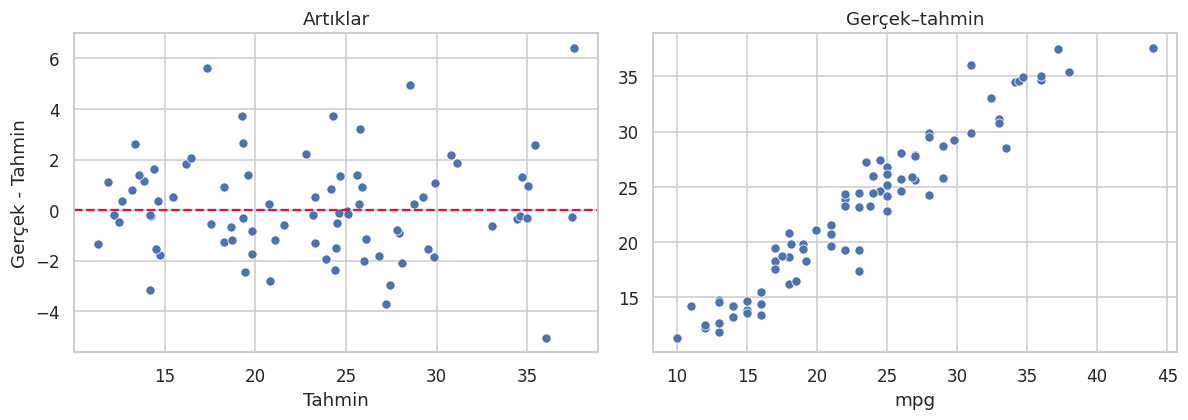

In [5]:
best_name = scores.index[0]; best_model = fitted[best_name]
best_pred = preds[best_name]
residual = y_test - best_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.scatterplot(x=best_pred, y=residual, ax=axes[0]); axes[0].axhline(0, ls="--", c="crimson")
axes[0].set(title="Artıklar", xlabel="Tahmin", ylabel="Gerçek - Tahmin")
sns.scatterplot(x=y_test, y=best_pred, ax=axes[1]); axes[1].set(title="Gerçek–tahmin")
plt.tight_layout(); plt.show()
joblib.dump({"best_name": best_name, "best_model": best_model, "all_models": fitted,
             "features": features, "metrics": scores.to_dict()},
            MODEL_DIR / "02_auto_mpg.joblib")
json.dump({"best_model": best_name, **scores.loc[best_name].to_dict()},
          open(RESULT_DIR / "02_auto_mpg.json", "w"), indent=2)

## Sonuç

Model seçimi test MAE değerine göre yapıldı. Artık grafiği, hatanın tahmin aralığı boyunca sistematik
bir desen oluşturup oluşturmadığını kontrol eder. `horsepower` sütunundaki gerçek eksikler eğitim
verisine göre medyanla dolduruldu; test bilgisinin ön işlemeye sızması engellendi.

## Kaynak çözümle karşılaştırma

Ödevde verilen proje listelerindeki örnek yaklaşımın odağı **araç özelliklerinden yakıt tüketimini tahmin etme** biçimindedir.
Bu notebookta **eksik değerleri Pipeline içinde ele alma, doğrusal/ağaç modeli karşılaştırma ve artık analizi** eklenmiştir. Böylece yalnızca modeli çalıştırmak yerine veri kalitesi,
EDA, görsel kanıt, uygun metrik ve yeniden kullanılabilir model kaydı birlikte sunulmuştur.

Kaynak listeler: [75 Data Science Projects](https://python.plainenglish.io/85-data-science-projects-c03c8750599e)
ve [230 Machine Learning Projects](https://medium.com/coders-camp/230-machine-learning-projects-with-python-5d0c7abf8265).